# Complete SVM Pipeline (from scratch)

## Step 1: Loads CIFAR-10 Dataset

In [1]:
#imports modules
import numpy as np
import matplotlib.pyplot as plt
import scipy
np.random.seed(42)

In [2]:
#function to extract images from CIFAR-10 readme
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [3]:
#function to extract images from CIFAR-10 readme - extracts only data and labels in x,y format
my_keys = [b'data',b'labels']
def unpickle_mod(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
        dict = {key:dict[key] for key in my_keys}
    return dict

In [4]:
#reads and 'unfolds' data from CIFAR-10 using helper function above - only x and y components
base_dir = r"/home/disk_2/Coding/CS231N/datasets/CIFAR10/cifar-10-python/cifar-10-batches-py/"
b1_mod = unpickle_mod(base_dir + r"data_batch_1") 
b2_mod = unpickle_mod(base_dir + r"data_batch_2")
b3_mod = unpickle_mod(base_dir + r"data_batch_3")
b4_mod = unpickle_mod(base_dir + r"data_batch_4")
b5_mod = unpickle_mod(base_dir + r"data_batch_5")
test_mod = unpickle_mod(base_dir + r"test_batch")

In [5]:
#reads english labels corresponding to numeric labels
eng_labels = unpickle(base_dir + r"batches.meta") 

#creates mapping for labels from numbers to english labels
label_map = dict(zip(range(10),eng_labels[b'label_names']))
label_map

{0: b'airplane',
 1: b'automobile',
 2: b'bird',
 3: b'cat',
 4: b'deer',
 5: b'dog',
 6: b'frog',
 7: b'horse',
 8: b'ship',
 9: b'truck'}

In [6]:
b1_mod[b'data'].shape

(10000, 3072)

In [7]:
#Note for self:Each batch of CIFAR-10 data contains 10K samples with 32x32 pixels x 3 channels = 3072. So each row in matrix is one image

## Step 2: Visualizing the dataset

b'deer'


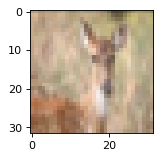

In [8]:
#set index to pull out an image
idx = 4000

#pull out image and label 
ex = b2_mod[b'data'][idx]
ex_label = b2_mod[b'labels'][idx]

#resize image from CIFAR10 data into 3-D numpy array -- note here that numpy follows (depth, rows, columns) nomenclature
ex_new = np.reshape(ex, (3,32,32))

#prints label and the image
print(label_map[ex_label])
plt.figure(figsize = (2,2), dpi = 80)
#even though numpy follows (depth, rows, columns) nomenclature, matlplotlib will take in (rows, columns, depth) hence the need for transpose
plt.imshow(ex_new.transpose(1, 2, 0)) 
plt.show()

## Step 3: Writing an SVM Classifier

### Step 3.1: Data Normalization

In [9]:
#running pre-processing in batches
def normalize_data(batch):
    batch_train = batch[b'data']
    batch_train_mean = batch_train.mean(axis=1).reshape(batch_train.shape[0],1)
    # print(batch_train_mean.shape)
    batch_train_var = batch_train.var(axis=1).reshape(batch_train.shape[0],1)
    # print(batch_train_var.shape)
    batch_train_x = (batch_train - batch_train_mean)/np.sqrt(batch_train_var)
    print(batch_train_x.shape)
    print(np.round(batch_train_x.mean(axis = 1).max(),2))
    print(np.round(batch_train_x.var(axis = 1).min(),2))
    return batch_train_x, batch_train_mean, batch_train_var

In [10]:
b1_mod_train_x = normalize_data(b1_mod)[0]
b2_mod_train_x = normalize_data(b2_mod)[0]
b3_mod_train_x = normalize_data(b3_mod)[0]
b4_mod_train_x = normalize_data(b4_mod)[0]
b5_mod_train_x = normalize_data(b5_mod)[0]
test_mod_x = normalize_data(test_mod)[0]

(10000, 3072)
0.0
1.0
(10000, 3072)
0.0
1.0
(10000, 3072)
0.0
1.0
(10000, 3072)
0.0
1.0
(10000, 3072)
0.0
1.0
(10000, 3072)
0.0
1.0


In [11]:
b1_mod_train_y = np.array(b1_mod[b'labels'], dtype = np.int8)
b2_mod_train_y = np.array(b2_mod[b'labels'], dtype = np.int8)
b3_mod_train_y = np.array(b3_mod[b'labels'], dtype = np.int8)
b4_mod_train_y = np.array(b4_mod[b'labels'], dtype = np.int8)
b5_mod_train_y = np.array(b5_mod[b'labels'], dtype = np.int8)
test_mod_y = np.array(test_mod[b'labels'], dtype = np.int8)

In [12]:
#memory mgt
del b1_mod,b2_mod,b3_mod,b4_mod,b5_mod

In [13]:
#qc
print(b1_mod_train_y.shape)
print(b1_mod_train_y.dtype)
print(test_mod_y.shape)
print(test_mod_y.dtype)

(10000,)
int8
(10000,)
int8


### Step 3.2 Writes an SVM Classifier and trains the model

In [14]:
class SVM(object):

    def __init__(self, x, y, num_classes = 10):
        self.num_classes = num_classes
        ones_col = np.ones((x.shape[0],1))
        self.x_train = np.hstack((ones_col,x))      
        self.y_train = y

        #initializes weights with small random values to generate unoptimized output scores
        self.W = (np.random.rand(self.x_train.shape[1], num_classes)) * 0.001

    def forward(self, reg_lambda = 0.05):
        #bias trick, add a column of ones in x_train matrix so that algo is only concerned about optimizing over W (weight matrix)
        self.reg_lambda = reg_lambda

        self.y_pred = self.x_train @ self.W

        #computes and prints loss
        #step1 : get the output score of the correct class
        self.x_comp = np.arange(len(self.y_train))
        self.y_comp = self.y_train
        self.scr_correct_class = self.y_pred[self.x_comp, self.y_comp].reshape(-1,1)

        #step2 : get the max of 0, difference in scores plus buffer
        #self.y_pred is scores of SVM over all classes for each instance in training set
        self.margins_int = (self.y_pred - self.scr_correct_class + 1)
        self.margins = np.maximum(np.zeros(self.y_pred.shape), self.margins_int)
        self.margins[np.arange(len(self.y_train)), self.y_train] = 0
        
        #step 3 : sum across all categories for each instance 
        #finally we take an average over all training examples
        #lastly, add regularization parameter - L2 reg
        self.N = self.x_train.shape[0]
        self.L = self.margins.sum() / self.N
        self.R = self.reg_lambda * ( (self.W**2).sum() )
        self.fin_loss = self.L + self.R

        return float(self.fin_loss)

    def backwards(self):
        #we will backpropogate step by step
        #Step 1: calculating gradient of final loss with respect to terms L and R
        #shape L = shape dL = 1
        #shape R = shape dR = 1
        dL = 1
        dR = 1
        
        #Step 2: calculating gradient of final loss with respect to margins
        #shape margins = shape dmargins = (10K,10)
        dmargins = (np.ones_like(self.margins)/self.N) * dL
        
        #Step 3: calculating gradient of final loss with respect to W in regularization term (R) - this is the first part of dW
        #shape W = shape dW_R = (3073,10)
        dW_R = (self.reg_lambda * 2 * self.W) * dR
        
        #Step 4: calculating gradient of final loss with respect to margins_int
        #shape margins_int = shape dmargins_int = (10K,10)
        dmargins_int = np.where( self.margins > 0, 1, 0) * dmargins
        
        #Step 5: calculating gradient of final loss with respect to y_pred - this is the first part of y_pred derivative
        #shape y_pred = shape dy_pred_1 = (10K,10)
        dy_pred = 1 * dmargins_int
        
        #Step 6: calculating gradient of final loss with respect to scr_correct_class
        #shape scr_correct_class = shape dscr_correct_class = (10K,1)
        dscr_correct_class = -1 * dmargins_int.sum(axis=1)

        #Step 7: calculating gradient of final loss with respect to y_pred - this is second part of y_pred derivative
        #shape y_pred = shape dy_pred = (10K,10)
        dy_pred[self.x_comp, self.y_comp] +=  dscr_correct_class

        #Step 8: calculating gradient final loss with respect to W - this is second part of W's gradient
        #shape W = shape dW = (3073,10)
        dW_X = (self.x_train.T @ dy_pred)
        dW = dW_R + dW_X

        #Step 9: calculating gradient final loss with respect to X
        #shape X = shape dX = (10K,3073)
        dX = dy_pred @ self.W.T
        
        return dW 

    def test_forward(self, x, y):
        ones_col = np.ones((x.shape[0],1))
        x_test = np.hstack((ones_col,x))
        y_test = y
        
        #generates prediction using trained weights from backward pass
        y_pred_test = x_test @ self.W

        #computes and prints loss
        #step1 : get the output score of the correct class
        x_comp_test = np.arange(len(y_test))
        y_comp_test = y_test
        scr_correct_class_test = y_pred_test[x_comp_test, y_comp_test].reshape(-1,1)

        #step2 : get the max of 0, difference in scores plus buffer
        #y_pred is scores of SVM over all classes for each instance in training set
        margins_int_test = (y_pred_test - scr_correct_class_test + 1)
        margins_test = np.maximum(np.zeros(y_pred_test.shape), margins_int_test)
        margins_test[np.arange(len(y_test)), y_test] = 0
        
        #step 3 : sum across all categories for each instance 
        #finally we take an average over all training examples
        #not including the regularization component here on purpose, we just want to look at actual loss
        N_test = x_test.shape[0]
        L_test = margins_test.sum() / N_test

        return float(L_test), y_pred_test

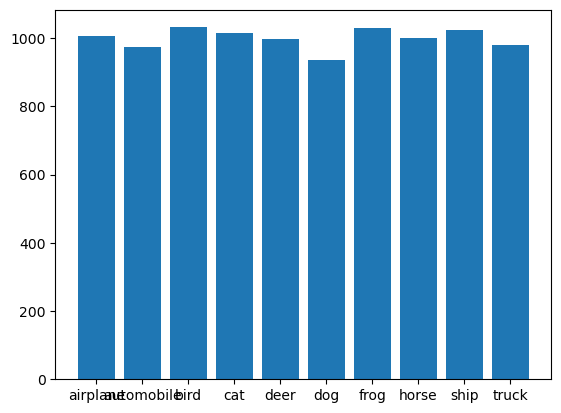

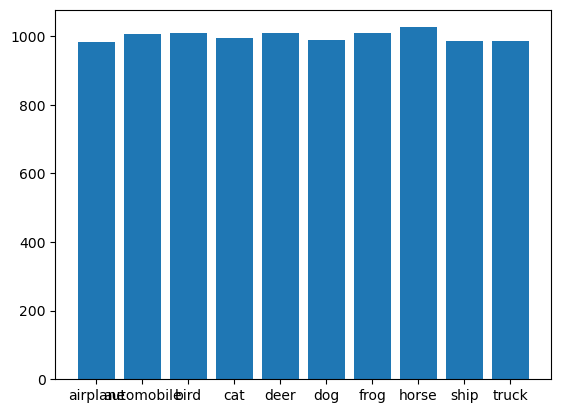

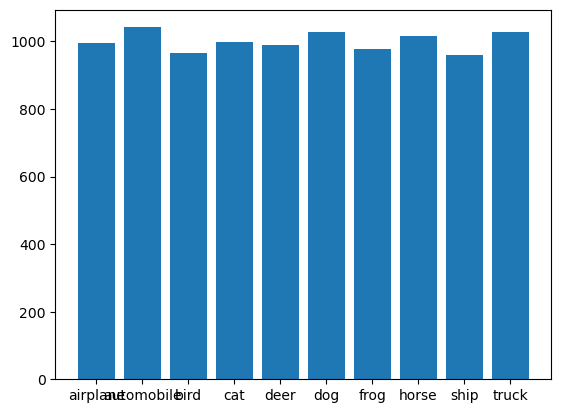

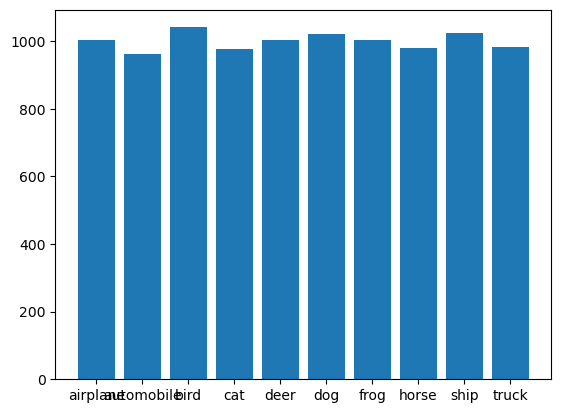

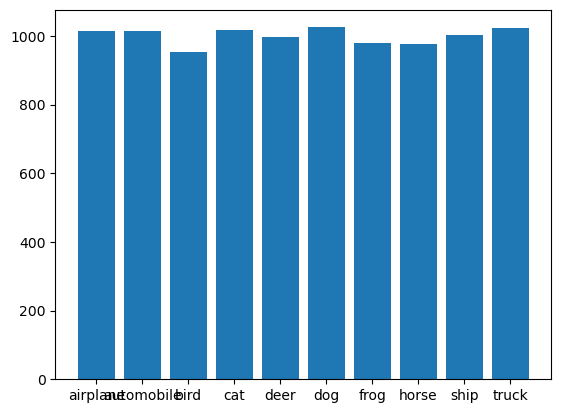

In [32]:
#I want to test if particular classes are overpresented in the provided chunks of training datasets. If yes, we will concatenate and shuffle the entire training set. If not, we will proceed as is.

labels_cat = [i for i in label_map.values()]
labels_cat

for i in [b1_mod_train_y, b2_mod_train_y, b3_mod_train_y, b4_mod_train_y, b5_mod_train_y]:
    label, freq = np.unique(i, return_counts = True)
    plt.bar(labels_cat, freq)
    plt.show()
#Shuffling not required, all classes seem to be represented equally in all chunks

In [15]:
#builds training datasets
train_x = np.concatenate((b1_mod_train_x, b2_mod_train_x, b3_mod_train_x, b4_mod_train_x))
train_y = np.concatenate((b1_mod_train_y, b2_mod_train_y, b3_mod_train_y, b4_mod_train_y))

In [17]:
#Stochastic gradient descent for SVM with learning rate decay
SVM_RK = SVM(x = train_x, y = train_y)

learning_rate = 0.01
sgd_iterations = 1000

for i in range(sgd_iterations):
    loss = SVM_RK.forward()

    dW = SVM_RK.backwards()
    #learning rate decay
    if (sgd_iterations - i) < 200:
        learning_rate = 0.001
    if i % 100 == 0:
        print('learning_rate : ' + str(learning_rate))
        print('loss : ' + str(loss))
        
    SVM_RK.W -= learning_rate * dW

learning_rate : 0.01
loss : 9.00786215548436
learning_rate : 0.01
loss : 6.280136773836855
learning_rate : 0.01
loss : 5.9095091095333325
learning_rate : 0.01
loss : 5.785462704114444
learning_rate : 0.01
loss : 5.690164775909084
learning_rate : 0.01
loss : 5.614220887655898
learning_rate : 0.01
loss : 5.554090334052045
learning_rate : 0.01
loss : 5.50990506621084
learning_rate : 0.01
loss : 5.472488606931957
learning_rate : 0.01
loss : 5.434053845265393
learning_rate : 0.01
loss : 5.402786975026475
learning_rate : 0.01
loss : 5.371205287809856
learning_rate : 0.01
loss : 5.343326377885958
learning_rate : 0.01
loss : 5.319822464187242
learning_rate : 0.01
loss : 5.299699459676723
learning_rate : 0.01
loss : 5.2816562639587525
learning_rate : 0.01
loss : 5.266351457322544
learning_rate : 0.01
loss : 5.247367873685444
learning_rate : 0.01
loss : 5.231516539722903
learning_rate : 0.01
loss : 5.218518404868157
learning_rate : 0.01
loss : 5.209291117026202
learning_rate : 0.01
loss : 5.1958

In [26]:
#note that initial loss of (num_category - 1) = 9 means that we are on the right track in terms of our implementation

### Step 3.3 Defines an accuracy class

In [19]:
#accuracy function
class accuracy(object):
    
    def __init__(self):
        pass
        
    def calculate(self, y_pred, y_true):
        self.y_pred = y_pred
        self.y_true = y_true
        #counts same labels, divides it by total size of array
        self.acc = np.count_nonzero((np.abs(y_pred-y_true))==0)/np.size(self.y_true)
        return float(self.acc)
    

# Step 4 : Testing on hold-out (development) set

In [27]:
loss, y_pred_dev = SVM_RK.test_forward(x = b5_mod_train_x, y = b5_mod_train_y)
print(loss)

4.55681569420387


In [28]:
#calculates accuracy
acc = accuracy()
acc.calculate(y_pred = np.argmax(y_pred_dev, axis = 1), y_true = b5_mod_train_y)

0.3798

# Step 5 : Moment of Truth : Scores on Test data

In [29]:
loss, y_pred_test = SVM_RK.test_forward(x = test_mod_x, y = test_mod_y)
print(loss)

4.539709787299717


In [30]:
#calculates accuracy
acc = accuracy()
acc.calculate(y_pred = np.argmax(y_pred_test, axis = 1), y_true = test_mod_y)

0.3788